In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
#Data from era5 curated by Copernicus :
#https://sites.ecmwf.int/data/c3sci/era5-daily/data/
file_path = '/Users/epauthen/Documents/Database/era5_sst_60S_60N/era5_daily_series_sst_natlantic_1979-2024_2.csv'

# Load the CSV file into a DataFrame
data = pd.read_csv(file_path, delimiter=';')
ds = xr.Dataset.from_dataframe(data)
ds = xr.Dataset.from_dataframe(data.set_index('date'))
ds['date'] = ds['date'].astype('datetime64')

ds['day_of_year'] = ds['date'].dt.dayofyear
ds['year'] = ds['date'].dt.year
ds = ds.set_coords('day_of_year')
ds = ds.set_coords('year')

#Create sst anomaly 1991-2020
ds_doy = ds.groupby('date.dayofyear')
ds_doy91_20 = ds.sel(date = slice('1991-01','2020-12')).groupby('date.dayofyear')
ano = (ds_doy - ds_doy91_20.mean(dim='date'))['sst'].data
ds = ds.assign(variables={"ano_91_20": (('date'), ano)})

ds1983 = ds.where(ds.year==1983)
ds1998 = ds.where(ds.year==1998)
ds2010 = ds.where(ds.year==2010)
ds2016 = ds.where(ds.year==2016)
ds2023 = ds.where(ds.year==2023)
ds2024 = ds.where(ds.year==2024)
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2023, ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'gold', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2023', '2024']

0.019
0.018


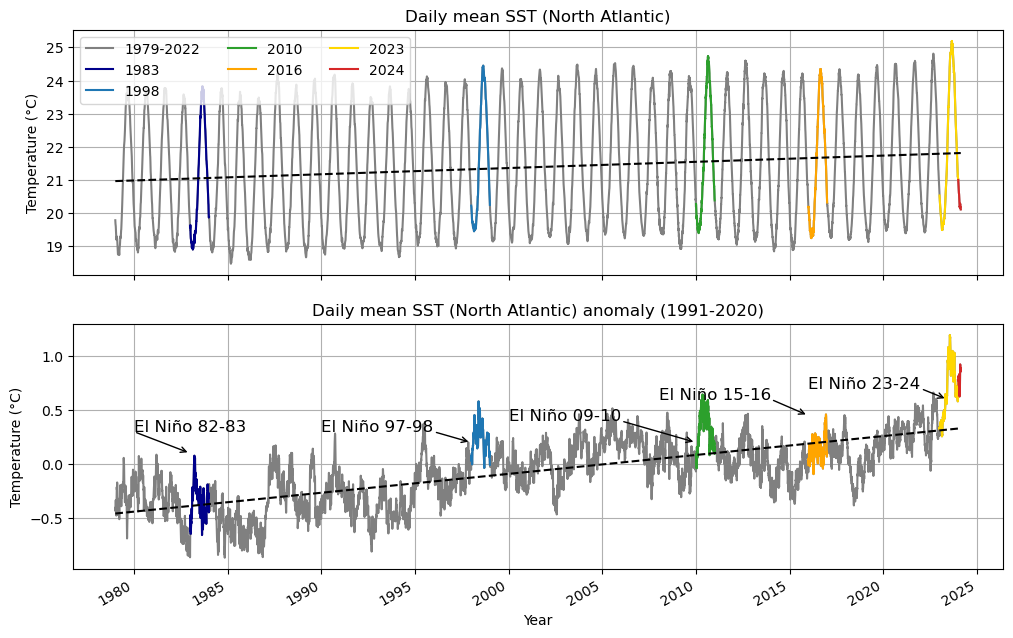

In [3]:
# Plotting
fig, (ax1,ax2) = plt.subplots(2, 1,figsize = (12,7))
for var,ax,title, in zip(['sst','ano_91_20'],[ax1,ax2],['Daily mean SST (North Atlantic)','Daily mean SST (North Atlantic) anomaly (1991-2020)']):
    ds[var].plot(label='1979-2022',color = 'grey',ax = ax)
    for i in np.arange(len(ds_list)):
        ds_list[i][var].plot(label=ds_lab[i], color=ds_col[i],ax = ax)
    # Linear regression for anomaly
    x_values = np.arange(len(ds['date'])).reshape(-1, 1)
    y_values = ds[var].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,3)
    print(slope)
    ax.plot(ds['date'], regression_line, linestyle='--', color='black') #label=f"Slope of the linear regression: {slope} °C/year"
    ax.set_title(title)
    ax.set_ylabel('Temperature (°C)')
    ax.grid()

ax2.text(pd.to_datetime('1980-01-01'), 0.3, 'El Niño 82-83' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('1983-01-01'), 0.1), xytext=(pd.to_datetime('1980-01-01'), 0.3),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('1990-01-01'), 0.3, 'El Niño 97-98' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('1998-01-01'), 0.2), xytext=(pd.to_datetime('1996-01-01'), 0.3),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2000-01-01'), 0.4, 'El Niño 09-10' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2010-01-01'), 0.2), xytext=(pd.to_datetime('2006-01-01'), 0.4),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2008-01-01'), 0.6, 'El Niño 15-16' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2016-01-01'), 0.45), xytext=(pd.to_datetime('2014-01-01'), 0.6),
            arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.text(pd.to_datetime('2016-01-01'), .7, 'El Niño 23-24' , fontsize=12, color='black')
ax2.annotate('', xy=(pd.to_datetime('2023-06-01'), 0.6), xytext=(pd.to_datetime('2022-01-01'), 0.7),
            arrowprops=dict(facecolor='black', arrowstyle='->'))

ax1.set_xlabel('')
ax2.set_xlabel('Year')
ax1.set_xticklabels([])
ax1.legend(ncol = 3)

plt.savefig('Fig_SST_NAtlantic.png')


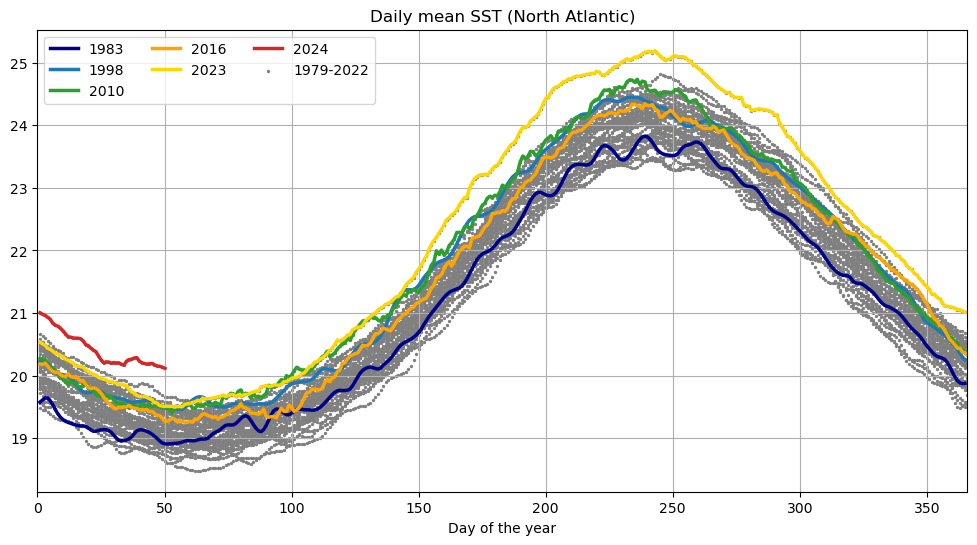

In [4]:
#Against day of the year for dramatic effect
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['sst'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['sst'],label=ds_lab[i], color=ds_col[i],linewidth = 2.5) #,s = 4)
plt.legend(ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST (North Atlantic)')
plt.savefig('Fig_SST2_NAtlantic.png')

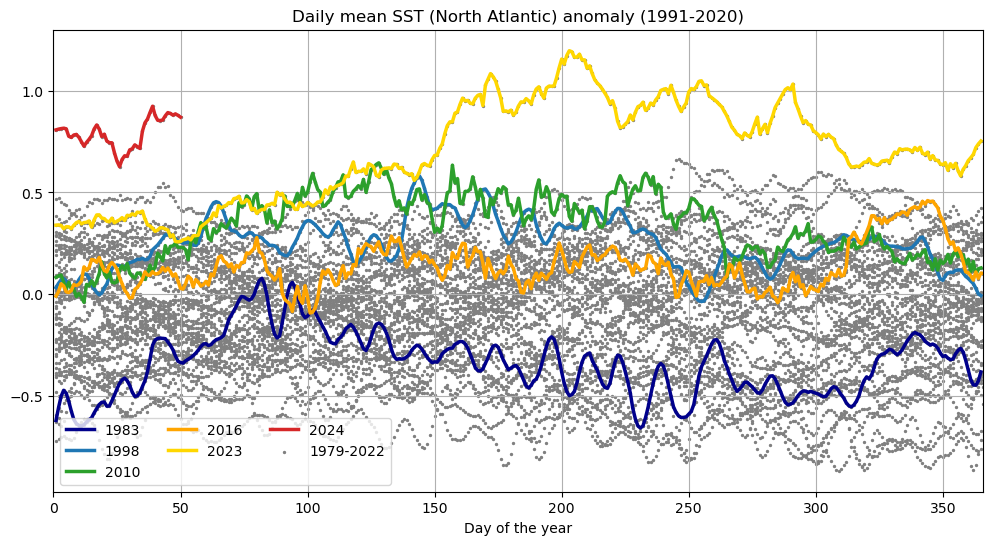

In [5]:
#Against day of the year for dramatic effect
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'],label=ds_lab[i], color=ds_col[i],linewidth = 2.5) #,s = 4)
plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST (North Atlantic) anomaly (1991-2020)')
plt.savefig('Fig_SST3_Natlantic.png')

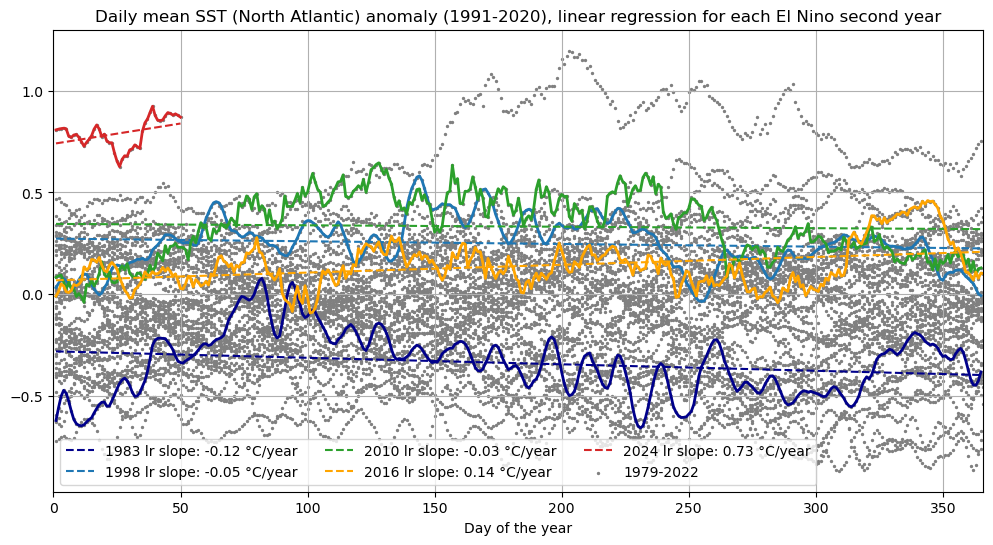

In [6]:
#Against day of the year for dramatic effect + linear trend for El Nino second year
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2024']
plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'], color=ds_col[i],linewidth = 2)

    # Linear regression for anomaly
    x_values = np.arange(len(ds_list[i].dropna(dim = 'date')['day_of_year'])).reshape(-1, 1)
    y_values = ds_list[i]['ano_91_20'].dropna(dim = 'date').values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,2)
    plt.plot(ds_list[i].dropna(dim = 'date')['day_of_year'], regression_line, linestyle='--', color=ds_col[i]
           ,label=f"{ds_lab[i]} lr slope: {slope} °C/year")
    
plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST (North Atlantic) anomaly (1991-2020), linear regression for each El Nino second year')
plt.savefig('Fig_SST4_NAtlantic.png')

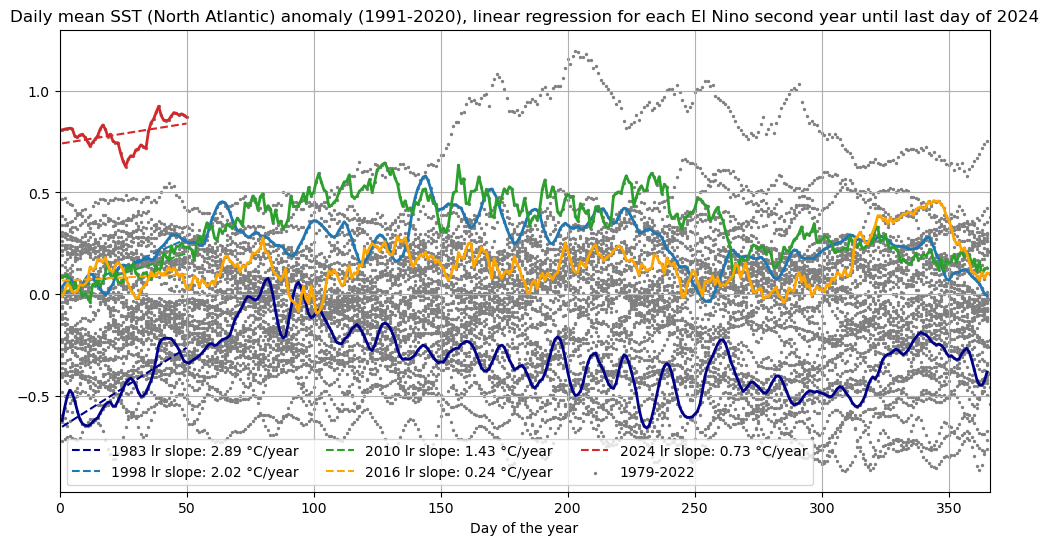

In [7]:
#Against day of the year for dramatic effect 
#+ linear trend for El Nino second year first 50 days to match 2024
ds_list = [ds1983    , ds1998   , ds2010    , ds2016 , ds2024]
ds_col  = ['darkblue','tab:blue','tab:green','orange', 'tab:red']
ds_lab  = ['1983'    ,'1998'    ,'2010'     ,'2016'  , '2024']

plt.figure(figsize=(12, 6))
plt.scatter(ds['day_of_year'], ds['ano_91_20'], color='grey',s = 2, label = '1979-2022')
for i in np.arange(len(ds_list)):
    plt.plot(ds_list[i]['day_of_year'], ds_list[i]['ano_91_20'], color=ds_col[i],linewidth = 2)

    # Linear regression for anomaly
    di = ds_list[i].dropna(dim = 'date')
    di = di.where((ds['day_of_year'] >= 1) & (ds['day_of_year'] <= 50)).dropna(dim = 'date')
    x_values = np.arange(len(di['day_of_year'])).reshape(-1, 1)
    y_values = di['ano_91_20'].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_values, y_values)
    regression_line = model.predict(x_values)
    slope = np.round(model.coef_[0][0]*365,2)
    plt.plot(di['day_of_year'], regression_line, linestyle='--', color=ds_col[i]
           ,label=f"{ds_lab[i]} lr slope: {slope} °C/year")

plt.legend(loc = 'lower left',ncol = 3)
plt.grid()
plt.xlim([0,366])
plt.xlabel('Day of the year')
plt.title('Daily mean SST (North Atlantic) anomaly (1991-2020), linear regression for each El Nino second year until last day of 2024')
plt.savefig('Fig_SST5_NAtlantic.png')

[Text(1, 0, 'January'),
 Text(31, 0, 'February'),
 Text(61, 0, 'March'),
 Text(91, 0, 'April'),
 Text(121, 0, 'May'),
 Text(151, 0, 'June'),
 Text(181, 0, 'July'),
 Text(211, 0, 'August'),
 Text(241, 0, 'September'),
 Text(271, 0, 'October'),
 Text(301, 0, 'November'),
 Text(331, 0, 'December'),
 Text(361, 0, '')]

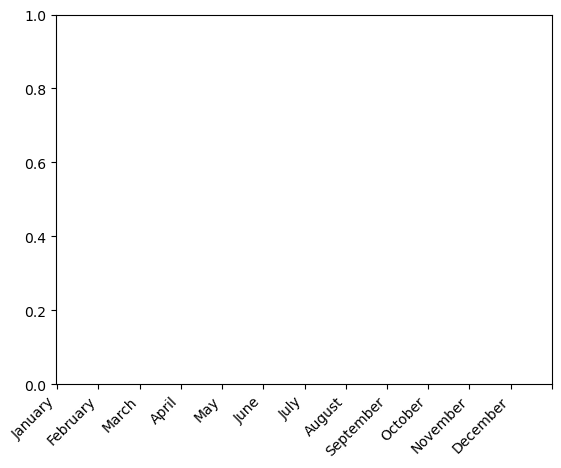

In [8]:
#Switch to months
months = ['January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December','']

plt.gca().set_xticks(ds.day_of_year[0:366][::30])  # Setting ticks at the beginning of each month
plt.gca().set_xticklabels(months, rotation=45, ha='right')  # Labeling with month names
